In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# <h4> Exploratory Analysis of Orders and Delivery Performance 

## <font size="4"> Load data

In [2]:
orders = pd.read_csv('../Data/Processed/orders.csv')
delivered_orders = pd.read_csv('../Data/Processed/delivered_orders.csv')
orders_items = pd.read_csv("../Data/Raw/olist_order_items_dataset.csv")

date_columns = ['order_purchase_timestamp',
                'order_approved_at',
                'order_delivered_carrier_date',
                'order_delivered_customer_date',
                'order_estimated_delivery_date'
                ]

for col in date_columns:
    orders[col] = pd.to_datetime(orders[col])
    delivered_orders[col] =pd.to_datetime(delivered_orders[col])

<font size="4"> Average delivery time <br>
<font size="2"> This section calculates the averagage number of days it takes for a delivered order to reach the customer

In [3]:
print(f"Average delivery time : {round(delivered_orders['delivery_days'].mean(),3)} days")

Average delivery time : 12.094 days


<font size="2"> Conclusion : This metric provides a general view of logistics efficiency by showing the typical delivery time for completed orders.

<font size="4">  On-time delivery rate <br>
<font size="2"> This section measures the proportion of delivered orders that arrived on or before the estimated delivery date.

In [5]:
print(f"One-time delivered day {delivered_orders['on_time'].mean():.2%}")

One-time delivered day 93.22%


<font size="2"> Conclusion : A high on-time delivery rate suggests that most completed orders met customer expectations in terms of estiamted delivery time.

<font size="4"> Orders by status distribution <br>
<font size="2"> This section shows how orders are distributed across different order statuses in the dataset.

In [22]:
orders['order_status'].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

<font size="2"> Conclusion: Most orders were successfully delivered, while a smaller proportion remained in intermediate or un favorable states such as shipperd, canceled or unavailable.

<font size="4"> Monthly order trend

In [6]:
orders['month'] = orders['order_purchase_timestamp'].dt.to_period('M')
orders.groupby('month')['order_id'].count()


month
2016-09       4
2016-10     324
2016-12       1
2017-01     800
2017-02    1780
2017-03    2682
2017-04    2404
2017-05    3700
2017-06    3245
2017-07    4026
2017-08    4331
2017-09    4285
2017-10    4631
2017-11    7544
2017-12    5673
2018-01    7269
2018-02    6728
2018-03    7211
2018-04    6939
2018-05    6873
2018-06    6167
2018-07    6292
2018-08    6512
2018-09      16
2018-10       4
Freq: M, Name: order_id, dtype: int64

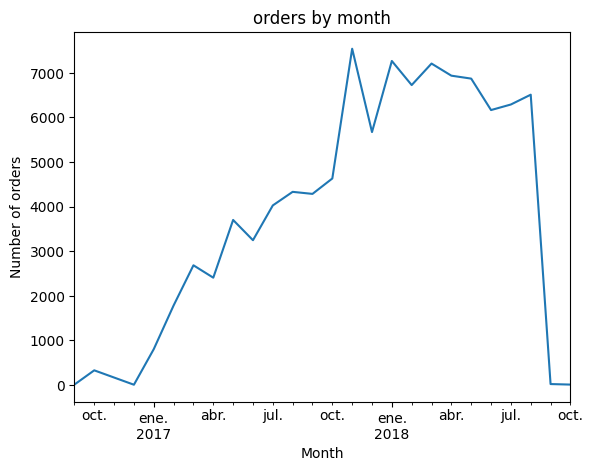

In [7]:
monthly_orders = orders.groupby('month')['order_id'].count()
monthly_orders.plot()
plt.title('orders by month')
plt.xlabel('Month')
plt.ylabel('Number of orders')
plt.show()

<font size="2"> Conclusion: The monthly trend helps reveal periods of higher and lower demand, which may indicate business growth or seasonal effects.

<font size="4"> Peak month by number of orders <br>


In [8]:
peak_month = monthly_orders.idxmax()
peak_orders = monthly_orders.max()
print(f"Peak month: {peak_month} | Orders: {peak_orders}")

Peak month: 2017-11 | Orders: 7544


<font size="2">Conclusion: Identifying the peak month helps highlight period of highest demand and may support planning for operations and inventory.

<font size="4"> Total number of orders 

In [9]:
print(f"Total orders: {orders['order_id'].count()}")

Total orders: 99441


<font size="4"> Late delivery rate

In [10]:
late_rate = 1- delivered_orders['on_time'].mean()
print(f"% pedidos retrasados: {late_rate:.2%}")

% pedidos retrasados: 6.78%


<font size="4"> Total delivered orders

In [11]:
print(f"Delivered orders: {delivered_orders['customer_id'].count()}")

Delivered orders: 96478


<font size="4"> Build sales table

In [12]:
##|order_id| total_price | total_freight | total_items

order_revenue = orders_items.groupby('order_id').agg(
    total_price = ('price', 'sum'),
    total_freight = ('freight_value', 'sum'),
    total_items = ('order_item_id', 'count')
).reset_index()

# sales : orders information, One-Time delivery, Revenue, number of products
sales = delivered_orders.merge(
    order_revenue,
    on='order_id',
    how='left'
)

<font size="4"> Revenue overview <br>
<font size="2"> This section summarizes key commercial metrics such as average ticket, total revenue and average number of items per order.

In [13]:
sales['total_revenue'] = sales['total_price'] + sales['total_freight']


print(f"Average ticket: {sales['total_revenue'].mean()}")
print(f"Total revenue: {sales['total_revenue'].sum()}")
print(f"Average number of items per order: {sales['total_items'].mean()}")

Average ticket: 159.82683876116837
Total revenue: 15419773.750000002
Average number of items per order: 1.1421982213561641


<font size="2"> Conclusion: These metrics provide a first commercial overview of the marketplace by showing how much revenue orders generate and how many items customers typically purchase per transaction.

<font size="4"> Monthly revenue trend

In [14]:

sales['month'] = sales['order_purchase_timestamp'].dt.to_period('M')
monthly_revenue = sales.groupby('month')['total_revenue'].sum()

In [15]:
sales.to_csv("../Data/Processed/sales.csv",index=False)

<font size="4"> Revenue visualization <br>
<font size="2">The following chart shows the monthly evolution of revenue across the observed period.

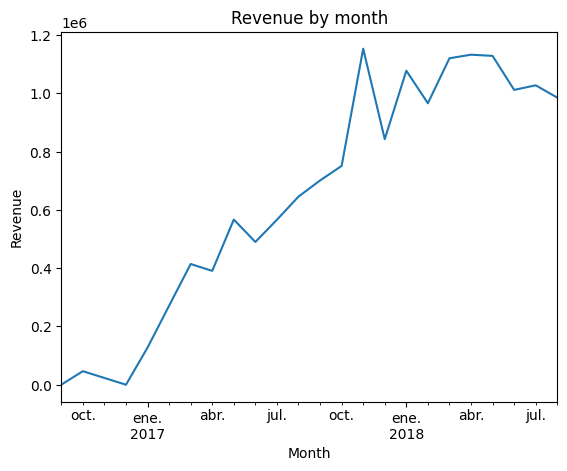

In [18]:
monthly_revenue.plot()

plt.title('Revenue by month')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.show()

<font size="2"> Peak revenue month

In [17]:
peak_revenue_month = monthly_revenue.idxmax()
peak_revenue_value = monthly_revenue.max()

print(f"Peak revenue month: {peak_revenue_month} | Revenue: {peak_revenue_value:.2f}")

Peak revenue month: 2017-11 | Revenue: 1153364.20


<font size="4"> **conclusions**
<font size="2">

- Delivery performance appears strong overall, with most orders arriving on time.
- Delivered orders represent the largest share of the dataset, while canceled or unavailable orders make up a smaller proportion.
- Order volume changes over time, suggesting demand fluctuations and possible seasonal behavior.
- The sales analysis shows that revenue is concentrated in specific months, with clear peaks in marketplace activity.
- This exploratory analysis provides a foundation for deeper business analysis, customer analytics, and predictive modeling.